In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
def perform_enrichment_test(
        df: pd.DataFrame,
        mut_label: str,
):
    
    case_mis = df[f'case.mis{mut_label}'].sum()
    case_syn = df[f'case.syn'].sum()
    control_mis = df[f'control.mis{mut_label}'].sum()
    control_syn = df[f'control.syn'].sum()

    contingency_table = np.array([
        [case_mis, case_syn],
        [control_mis, control_syn]
    ])
    
    oddsratio, pvalue = fisher_exact(contingency_table, alternative='greater')

    return {
        'case_mis': case_mis,
        'case_syn': case_syn,
        'case_mis_syn': case_mis / case_syn,
        'control_mis': control_mis,
        'control_syn': control_syn,
        'control_mis_syn': control_mis / control_syn,
        'oddsratio': oddsratio,
        'pvalue': pvalue
    }

In [3]:
# Load ASD-related genes
ASD_related_gene = [line.strip() for line in open(
    'data/ASD-related_gene.lst', 'r'
)]

In [4]:
# Read data (supplementary table from https://www.nature.com/articles/s41588-022-01104-0)
def read_data(filepath):

    data = pd.read_csv(
        filepath,
        sep='\t'
    )

    data_RDH = data[
        data['gene'].str.startswith('HIST')
    ]
    data_RDH = data_RDH[
        data_RDH['gene'].str.contains('H1') == False
    ]

    data['is_cRDH'] = False
    data.loc[data.index.isin(data_RDH.index), 'is_cRDH'] = True

    data['is_ASD'] = False
    data.loc[data['gene'].isin(ASD_related_gene), 'is_ASD'] = True

    data['is_OG'] = True
    data.loc[data['is_cRDH'] | data['is_ASD'], 'is_OG'] = False

    for sample in ['case', 'control']:
        data[f'{sample}.mis.all'] = data[f'{sample}.misb'] + data[f'{sample}.misa'] + data[f'{sample}.mis']
        data[f'{sample}.mis.a+b'] = data[f'{sample}.misb'] + data[f'{sample}.misa']

    return data

case_control_pergene_data = read_data('data/Fu2022_Nature_autism_denovo_snv-indel.ST7.per-gene_case-control-count.csv')

In [5]:
plot_gene_types = ['ASD', 'cRDH', 'OG']
df = pd.DataFrame(
    columns=['Gene', 'Value', 'P', 'Mistype']
)

for title, mut_label in zip(
    ['Mis MPC>2', 'Mis 2>MPC>1', 'Mis 1>MPC', 'All Mis'],
    ['b', 'a', '', '.all']
):

    case_control_ratio = []
    results_lst = []

    for gene_type in plot_gene_types:

        results = perform_enrichment_test(
            case_control_pergene_data[case_control_pergene_data[f'is_{gene_type}']],
            mut_label
        )

        df = df._append(
            {
            'Gene': gene_type,
            'Value': results['case_mis_syn'] / results['control_mis_syn'],
            'P': results['pvalue'],
            'Mistype': title
            }, ignore_index=True
        )

df['Value'] = np.log2(df['Value'].astype(float))

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


Text(0.8, 1, '*** $P$ < 0.001\n ** $P$ < 0.01\n  * $P$ < 0.05')

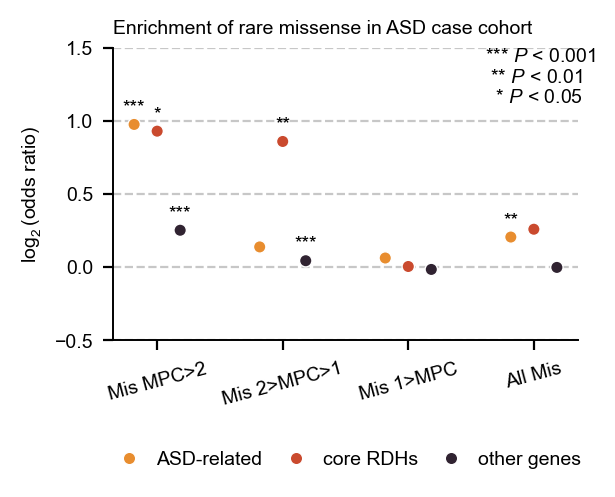

In [6]:
# Prepare for plotting
mistype_order = ['Mis MPC>2', 'Mis 2>MPC>1', 'Mis 1>MPC', 'All Mis']
gene_colors = {
    'ASD': '#E88D2F',
    'cRDH': '#CA4A2E',
    'OG': '#302331',
    'Top45': '#3BA595',
}

df['x'] = df['Mistype'].map(lambda x: mistype_order.index(x))
offset_total = 0.55
gene_offsets = {
    'ASD': -offset_total/3,
    'cRDH': 0,
    'OG': offset_total/3
}
df['x'] += df['Gene'].map(gene_offsets)

# Plot
fig, ax = plt.subplots(figsize=(3, 2))

sns.scatterplot(
    data=df,
    ax=ax,
    x='x',
    y='Value',
    hue='Gene',
    palette=gene_colors,
    s=20,
    edgecolor='w',
    linewidth=0.5,
    zorder=3
)

ax.set_xticks(
    ticks=[0, 1, 2, 3],
    labels=mistype_order
)
ax.set_xlabel('')
ax.set_ylabel(r'$\log_2(\mathrm{odds\ ratio})$')
ax.set_ylim(-0.5, 1.5)
ax.grid(True, axis='y', ls='--', alpha=0.7, zorder=0)

def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for _, row in df.iterrows():
    ax.text(
        x=row['x'],
        y=row['Value'] + 0.05,
        s=get_significance(row['P']),
        ha='center',
        va='bottom',
        color='k',
        fontsize=7,
    )

plt.title('Enrichment of rare missense in ASD case cohort', pad=5, loc='left')
plt.tight_layout()

# Customize legend
handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[
        'ASD-related',
        'core RDHs',
        'other genes',
    ],
    bbox_to_anchor=(0.5, -0.5),
    loc='lower center',
    ncols=4,
    frameon=False,
    columnspacing=0.7,
    handletextpad=0.4
)

ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_tick_params(rotation=15)

# Annotate
ax.text(
    s='*** $P$ < 0.001\n ** $P$ < 0.01\n  * $P$ < 0.05',
    x=0.8,
    y=1,
    transform=ax.transAxes,
    ha='left',
    va='top',
)